In [1]:
pip install fastapi uvicorn joblib

  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached idna-3.20-py3-none-any.whl.metadata (7.2 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
Using cached click-8.5.0-py3-none-any.whl (125 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 209.0 kB/s eta 0:00:08
   ---------- ----


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [3]:
# Load data
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Prepare data
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(subset=["TotalCharges"]).copy()

data["ChurnFlag"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Features and target
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = data[features]
y = data["ChurnFlag"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_scaled, y)

# Save model and scaler
joblib.dump(model, "day43_churn_model.pkl")
joblib.dump(scaler, "day43_scaler.pkl")

print("Model trained and saved successfully!")
print("Model: Logistic Regression")
print("Features:", features)

Model trained and saved successfully!
Model: Logistic Regression
Features: ['tenure', 'MonthlyCharges', 'TotalCharges']


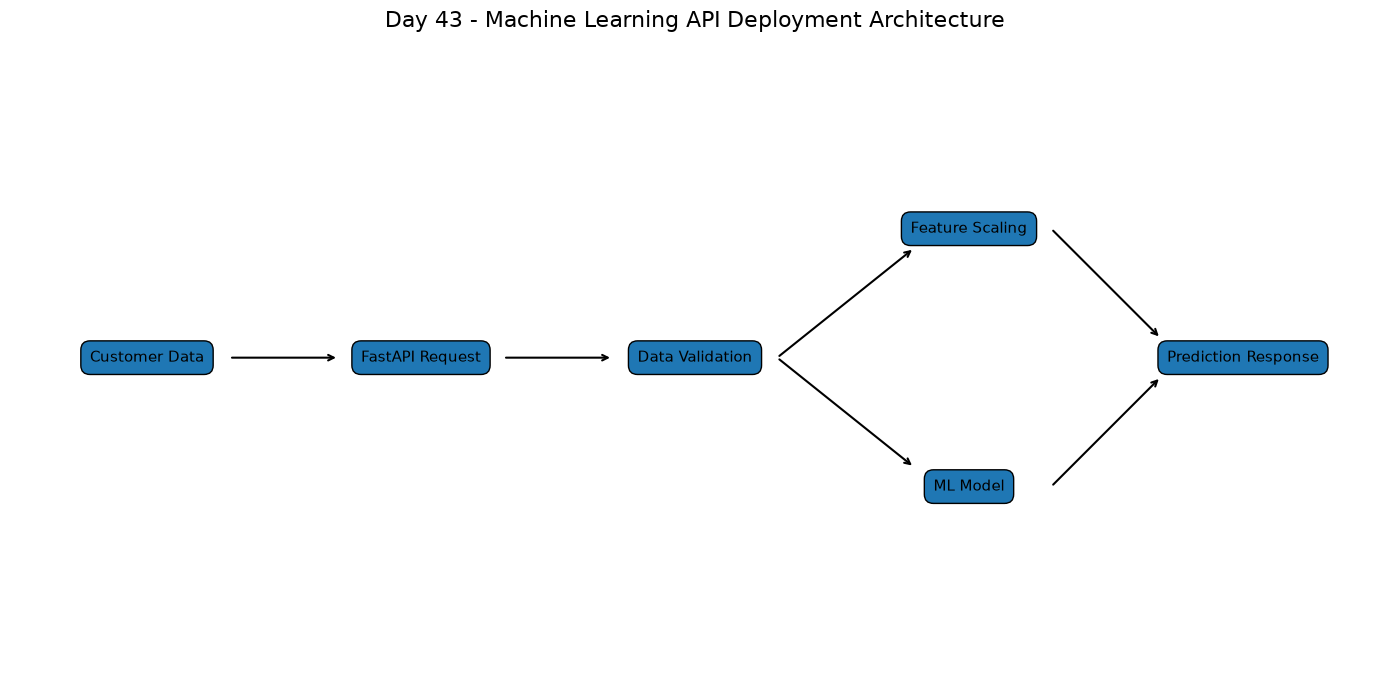

API architecture diagram created successfully!


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

steps = [
    ("Customer Data", 0.10, 0.50),
    ("FastAPI Request", 0.30, 0.50),
    ("Data Validation", 0.50, 0.50),
    ("Feature Scaling", 0.70, 0.70),
    ("ML Model", 0.70, 0.30),
    ("Prediction Response", 0.90, 0.50)
]

for text, x, y in steps:
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.6", edgecolor="black")
    )

arrows = [
    ((0.16, 0.50), (0.24, 0.50)),
    ((0.36, 0.50), (0.44, 0.50)),
    ((0.56, 0.50), (0.66, 0.67)),
    ((0.56, 0.50), (0.66, 0.33)),
    ((0.76, 0.70), (0.84, 0.53)),
    ((0.76, 0.30), (0.84, 0.47))
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.set_title(
    "Day 43 - Machine Learning API Deployment Architecture",
    fontsize=16
)

plt.tight_layout()
plt.savefig("day43_api_architecture.png", dpi=300)
plt.show()

print("API architecture diagram created successfully!")